# Insect + Drone sound together


In [5]:
import librosa
import numpy as np
import math
import logging

l_fmt = '[%(levelname)s] %(asctime)s - %(message)s'
logging.basicConfig(level=logging.ERROR, format=l_fmt)
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

SOUND_FOLDER = '../data/sound'
WAV_PATH = f'{SOUND_FOLDER}/insect-drone.wav'
orig_sr = librosa.get_samplerate(WAV_PATH)
logger.info(f'orginal sample rate is: {orig_sr}')

def get_wav_ceil_duration(y, sr) -> int:
    duration = librosa.get_duration(y=data, sr=sr)
    logger.debug('sound duration: {duration}')
    duration = int(math.ceil(duration))
    logger.debug(f'sound ceil duration: {duration}')

    return duration

data, sr = librosa.load(WAV_PATH, mono=True)
logger.info(f'data shape: {data.shape}')
logger.info(f'sr: {sr}')
TIME = get_wav_ceil_duration(data, sr)
data = librosa.util.fix_length(data, size=sr*TIME)
N = data.shape[0]
logger.info(f'N is {N}')

logger.info(f'data:\n{data[2000:2050]}')

[INFO] 2022-10-18 13:35:24,171 - orginal sample rate is: 44100
[INFO] 2022-10-18 13:35:24,617 - data shape: (709632,)
[INFO] 2022-10-18 13:35:24,617 - sr: 22050
[DEBUG] 2022-10-18 13:35:24,618 - sound duration: {duration}
[DEBUG] 2022-10-18 13:35:24,618 - sound ceil duration: 33
[INFO] 2022-10-18 13:35:24,620 - N is 727650
[INFO] 2022-10-18 13:35:24,621 - data:
[-5.9137265e-03 -5.0441553e-03 -1.4124853e-03 -3.1730277e-04
  4.0651830e-03  8.4425317e-04  1.1982436e-03  3.0296845e-03
  1.7321837e-03 -2.2667660e-03 -4.6342406e-03 -4.9172044e-03
  1.2258490e-03  2.2979730e-03  1.4562643e-03  6.7087603e-03
  2.3941298e-03  5.1561524e-03  4.1790199e-03  2.9326249e-03
  4.6669701e-03  2.1845517e-03 -1.4893212e-03 -3.9504576e-03
 -2.8435527e-03 -5.0791563e-03 -3.8583085e-03 -2.8401513e-03
  2.8155076e-03  5.5003017e-03  3.4240568e-03  2.5928686e-03
 -2.7390898e-03 -3.6986794e-03 -2.4132188e-03  1.0526959e-03
 -8.7841001e-04 -4.1778847e-03  3.2244613e-03  2.7923209e-03
 -4.4915818e-05  3.5765016

## Play the sound

In [6]:
import IPython
IPython.display.Audio(WAV_PATH)

## Plot the sound

Text(0.5, 1.0, 'Mono')

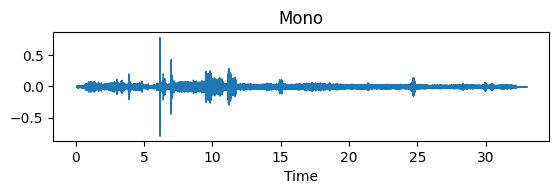

In [7]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure()
plt.subplot(3, 1, 2)
librosa.display.waveshow(y=data, sr=sr)
plt.title('Mono')

## Drone sound

Text(0.5, 1.0, 'Drone Mono')

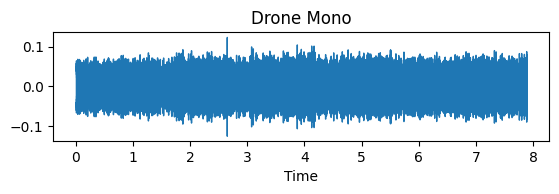

In [8]:
DRONE_WAV_FN = f'{SOUND_FOLDER}/drone-only.m4a'
drone_data, drone_sr = librosa.load(DRONE_WAV_FN, mono=True)

plt.figure()
plt.subplot(3, 1, 2)
librosa.display.waveshow(y=drone_data, sr=drone_sr)
plt.title('Drone Mono')

## plot specgram

[librosa melspectrogram](https://librosa.org/doc/main/generated/librosa.feature.melspectrogram.html)

[Text(0.5, 1.0, 'Mel-frequency spectrogram')]

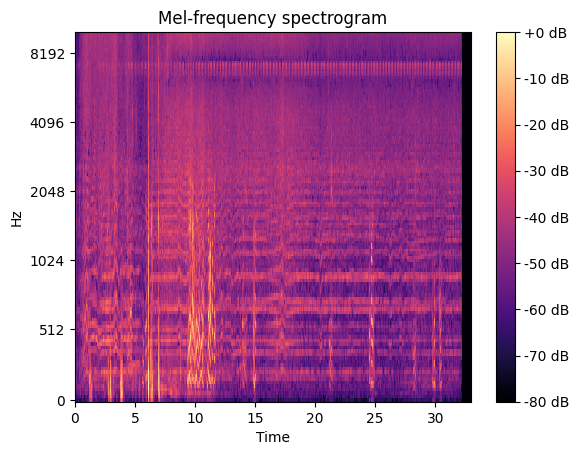

In [9]:
F_MAX = 10000
S = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128, fmax=F_MAX)

fig, ax = plt.subplots()
S_db = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_db, x_axis='time', y_axis='mel', sr=sr, fmax=F_MAX, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')



## plot drone spectrogram

[Text(0.5, 1.0, 'Mel-frequency spectrogram')]

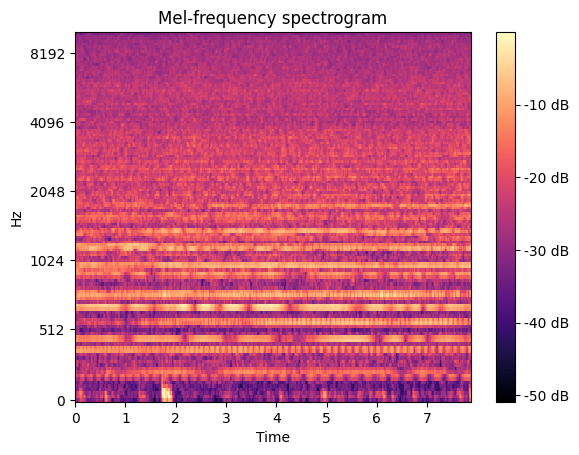

In [10]:
S_drone = librosa.feature.melspectrogram(y=drone_data, sr=drone_sr, n_mels=128, fmax=F_MAX)

fig, ax = plt.subplots()
S_db_drone = librosa.power_to_db(S_drone, ref=np.max)
img = librosa.display.specshow(S_db_drone, x_axis='time', y_axis='mel', sr=drone_sr, fmax=F_MAX, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')

## Remove drone noise

[Noise reduction using spectral gating in python](https://timsainburg.com/noise-reduction-python.html)

In [11]:
import soundfile as sf
import noisereduce as nr

data, rate = librosa.load(WAV_PATH)
#drone_data, drone_rate = librosa.load(DRONE_WAV_FN)
#reduced_noise = nr.reduce_noise(y=data, sr=rate, y_noise=drone_data)
reduced_noise = nr.reduce_noise(y=data, sr=rate)
reduce_fn = '../data/sound/reduced-insect-drone.wav'
sf.write(reduce_fn, reduced_noise, rate)

IPython.display.Audio(reduce_fn)

## Plot spectrogram of reduced wave

[Text(0.5, 1.0, 'Reduced spectrogram')]

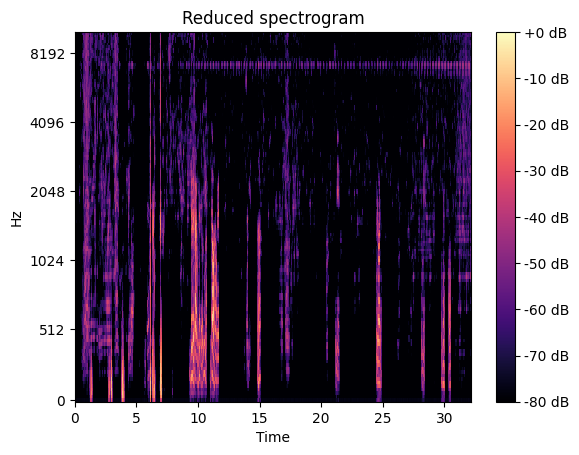

In [12]:
data, sr = librosa.load(reduce_fn, mono=True)
S = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128, fmax=F_MAX)

fig, ax = plt.subplots()
S_db = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_db, x_axis='time', y_axis='mel', sr=sr, fmax=F_MAX, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Reduced spectrogram')

data type: float32
data size should be 2838528.0
size of rd_file data: 2838528
size of x: 1419264, memory of x 5677056
num of scales: 97
scales:
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.429

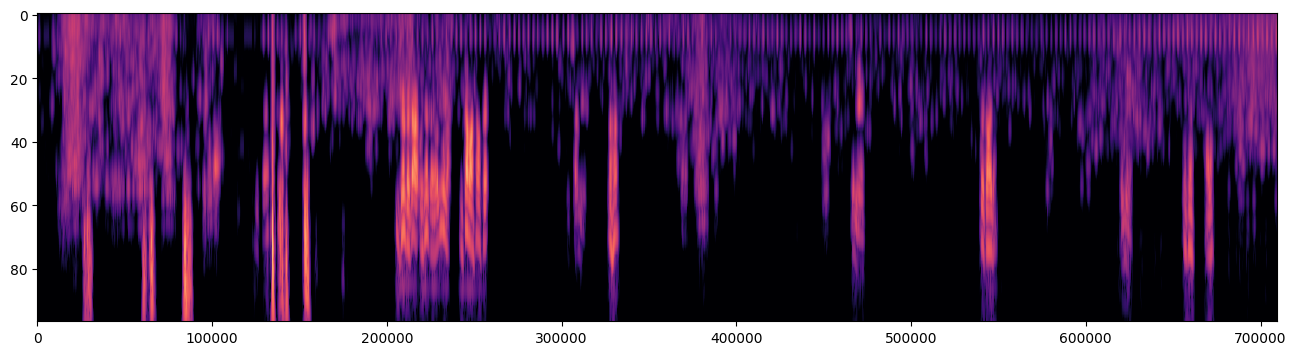

In [13]:
import sys
import os

sys.path.insert(0, os.path.abspath('../dataprocess'))
from dataprocess.cwt,cwt2 import rd_file, cwt2

SR = 22050
CMAP = 'magma'

data = rd_file(reduce_fn)
cs1, f1 = cwt2(data, nv=12, sr=SR, low_freq=40)
plt.figure(figsize = (16,4))
plt.imshow(20*np.log10(np.abs(cs1)), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-100)
plt.show()